In [4]:
import geopandas as gpd
import pandas as pd
import fiona

gpkg_path = r"C:\SoilGrids\data\Ubicacion_Estacion Principal.gpkg"
layers = fiona.listlayers(gpkg_path)

records = []
source_crs = None

for layer_name in layers:
    gdf = gpd.read_file(gpkg_path, layer=layer_name)
    if gdf.empty:
        continue

    point_rows = gdf[gdf.geometry.geom_type.isin(["Point", "MultiPoint"])].copy()
    if point_rows.empty:
        continue

    source_crs = gdf.crs
    point_rows["x"] = point_rows.geometry.x
    point_rows["y"] = point_rows.geometry.y
    point_rows["layer"] = layer_name

    if source_crs is not None:
        point_rows_wgs84 = point_rows.to_crs(4326)
        point_rows["longitude"] = point_rows_wgs84.geometry.x
        point_rows["latitude"] = point_rows_wgs84.geometry.y
    else:
        point_rows["longitude"] = pd.NA
        point_rows["latitude"] = pd.NA

    records.append(point_rows[["layer", "x", "y", "longitude", "latitude", "geometry"]])

if not records:
    raise ValueError("No point geometries were found in the geopackage.")

coords_df = pd.concat(records, ignore_index=True)
print(f"Layers: {list(layers)}")
print(f"Source CRS: {source_crs}")
coords_df

Layers: ['Ubicacion_Estacion Principal']
Source CRS: EPSG:24877


,layer,x,y,longitude,latitude,geometry
0,Ubicacion_Estacion Principal,696444.80038,9.661710e+06,-79.234636,-3.062424,POINT (696444.8 9661710.265)


In [1]:
import pandas as pd
import numpy as np

# Load TDR data
tdr_path = r"TDR_data\TDR_ladera_zhurucay_2021_09_2026_03.csv"
df_tdr = pd.read_csv(tdr_path, parse_dates=["TIMESTAMP"])

# Drop duplicate timestamps if any
df_tdr = df_tdr.drop_duplicates(subset="TIMESTAMP")

# Set TIMESTAMP as index and resample to daily mean
df_tdr = df_tdr.set_index("TIMESTAMP")
df_day = df_tdr.resample("D").mean()
df_day.index.name = "Date"

# Save daily averages to a new CSV
output_path = r"TDR_data\TDR_ladera_zhurucay_daily_avg.csv"
df_day.to_csv(output_path)

print(f"Daily averages saved to: {output_path}")
print(f"Shape: {df_day.shape}")
df_day.head()


Daily averages saved to: TDR_data\TDR_ladera_zhurucay_daily_avg.csv
Shape: (1659, 12)


,VW_Avg(14),VW_Avg(15),VW_Avg(16),VW_Avg(17),VW_Avg(18),VW_Avg(19),VW_Avg(20),VW_Avg(21),VW_Avg(22),VW_Avg(23),VW_Avg(24),VW_Avg(25)
Date,,,,,,,,,,,,
2021-09-10,0.732906,0.702226,0.726562,0.692944,0.734441,0.762181,0.705681,0.363260,0.678861,0.722021,0.661292,0.819569
2021-09-11,0.733330,0.715705,0.727122,0.691111,0.739132,0.762163,0.706198,0.361917,0.681104,0.722816,0.661615,0.824972
2021-09-12,0.740552,0.736747,0.740740,0.713205,0.751632,0.772743,0.720292,0.394344,0.700215,0.733312,0.696274,0.837531
2021-09-13,0.768399,0.747740,0.757146,0.743052,0.759663,0.778705,0.721969,0.399878,0.707507,0.733139,0.687767,0.836868
2021-09-14,0.759649,0.722806,0.740396,0.729174,0.748774,0.770851,0.712701,0.375840,0.686802,0.728819,0.672569,0.826424


In [2]:
# Compute the mean across all sensors for each day
df_day_mean = df_day.mean(axis=1).rename("VW_mean_all_sensors").to_frame()
df_day_mean.index.name = "Date"

# Save to CSV
output_mean_path = r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv"
df_day_mean.to_csv(output_mean_path)

print(f"Saved to: {output_mean_path}")
print(f"Shape: {df_day_mean.shape}")
df_day_mean.head()


Saved to: TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv
Shape: (1659, 1)


,VW_mean_all_sensors
Date,
2021-09-10,0.691829
2021-09-11,0.693932
2021-09-12,0.711466
2021-09-13,0.720153
2021-09-14,0.706234


In [12]:
import pandas as pd

# Find missing dates in daily mean soil moisture series
daily_path = r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv"
df_daily = pd.read_csv(daily_path, parse_dates=["Date"])

df_daily = df_daily.drop_duplicates(subset="Date").sort_values("Date")
df_daily = df_daily.set_index("Date")

full_days = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq="D")

# A date is missing if it is absent from the index OR present but value is NaN
missing_from_index = full_days.difference(df_daily.index)
nan_days = df_daily.index[df_daily["VW_mean_all_sensors"].isna()]
all_missing_days = pd.DatetimeIndex(sorted(set(missing_from_index).union(set(nan_days))))

missing_dates_df = pd.DataFrame({"date": all_missing_days.date})
out_missing_dates = r"resultados\missing_dates_daily_mean_all_sensors.csv"
missing_dates_df.to_csv(out_missing_dates, index=False)

# Build summary of consecutive missing-date gaps
gap_rows = []
if len(all_missing_days) > 0:
    s = pd.Series(all_missing_days)
    group_id = (s.diff().dt.days.ne(1)).cumsum()

    for _, grp in s.groupby(group_id):
        start = grp.iloc[0]
        end = grp.iloc[-1]
        length_days = len(grp)
        gap_rows.append({
            "start_date": start.date(),
            "end_date": end.date(),
            "length_days": int(length_days)
        })

gaps_df = pd.DataFrame(gap_rows).sort_values("length_days", ascending=False) if gap_rows else pd.DataFrame(columns=["start_date", "end_date", "length_days"])
out_gaps_summary = r"resultados\missing_gaps_summary_daily_mean_all_sensors.csv"
gaps_df.to_csv(out_gaps_summary, index=False)

print("Missing-date audit complete for daily mean CSV")
print(f"Date range checked: {full_days.min().date()} to {full_days.max().date()}")
print(f"Missing from index: {len(missing_from_index)}")
print(f"NaN days in VW_mean_all_sensors: {len(nan_days)}")
print(f"Total unique missing dates: {len(all_missing_days)}")
print(f"Saved missing dates to: {out_missing_dates}")
print(f"Saved gap summary to: {out_gaps_summary}")

if len(all_missing_days) > 0:
    print("\nFirst 30 missing dates:")
    print(pd.Series(all_missing_days.date).head(30).to_string(index=False))

if len(gaps_df) > 0:
    print("\nTop 10 largest consecutive missing-date gaps:")
    print(gaps_df.head(10).to_string(index=False))

gaps_df.head(10)

Missing-date audit complete for daily mean CSV
Date range checked: 2021-09-10 to 2026-03-26
Missing from index: 0
NaN days in VW_mean_all_sensors: 246
Total unique missing dates: 246
Saved missing dates to: resultados\missing_dates_daily_mean_all_sensors.csv
Saved gap summary to: resultados\missing_gaps_summary_daily_mean_all_sensors.csv

First 30 missing dates:
2023-08-04
2023-08-05
2023-08-06
2023-08-07
2023-08-08
2023-08-09
2024-01-26
2024-01-27
2024-01-28
2024-01-29
2024-01-30
2024-01-31
2024-02-01
2024-02-02
2024-02-03
2024-02-04
2024-02-05
2024-02-06
2024-02-07
2024-02-08
2024-02-09
2024-02-10
2024-02-11
2024-02-12
2024-02-13
2024-02-14
2024-02-15
2024-02-16
2024-02-17
2024-02-18

Top 10 largest consecutive missing-date gaps:
start_date   end_date  length_days
2024-03-22 2024-08-15          147
2024-01-26 2024-02-21           27
2025-11-20 2025-12-03           14
2026-02-27 2026-03-12           14
2025-08-29 2025-09-10           13
2025-12-19 2025-12-31           13
2025-08-01 20

,start_date,end_date,length_days
2,2024-03-22,2024-08-15,147
1,2024-01-26,2024-02-21,27
5,2025-11-20,2025-12-03,14
7,2026-02-27,2026-03-12,14
4,2025-08-29,2025-09-10,13
6,2025-12-19,2025-12-31,13
3,2025-08-01,2025-08-12,12
0,2023-08-04,2023-08-09,6


Overlapping days: 1412

        TDR_mean  SMAP_mean
count  1412.0000  1412.0000
mean      0.6652     0.2542
std       0.4140     0.0694
min     -14.8037     0.1084
25%       0.6596     0.1981
50%       0.6838     0.2578
75%       0.7028     0.3052
max       0.7701     0.3847

--- Comparison statistics (SMAP vs TDR) ---
  N              : 1412
  Bias           : -0.4110  cm³/cm³
  RMSE           : 0.5855  cm³/cm³
  MAE            : 0.4324  cm³/cm³
  Pearson r      : 0.0376  (p=1.5764e-01)
  Spearman ρ     : 0.4979  (p=2.4150e-89)
  Lin. slope     : 0.0063
  Willmott d     : 0.1015

  Wilcoxon W     : 1412.0  (p=4.4718e-231)


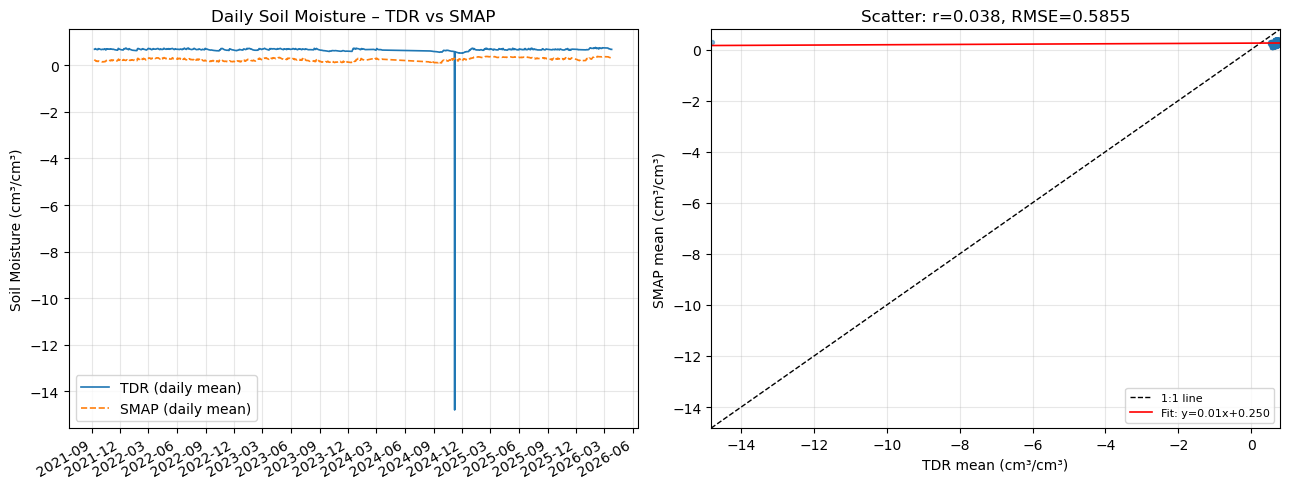

Figure saved to resultados/TDR_vs_SMAP_comparison.png


In [3]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Load data ---
df_tdr_daily = pd.read_csv(
    r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv",
    parse_dates=["Date"], index_col="Date"
)

df_smap = pd.read_csv(
    r"TDR_data\SMAP_zhurucay_clean.csv",
    parse_dates=["timestamp"]
)

# Resample SMAP to daily mean
df_smap_daily = (
    df_smap.set_index("timestamp")["soil_moisture"]
    .resample("D").mean()
    .rename("SMAP_soil_moisture")
    .to_frame()
)
df_smap_daily.index.name = "Date"

# --- Merge on date ---
df_cmp = df_tdr_daily.join(df_smap_daily, how="inner")
df_cmp.columns = ["TDR_mean", "SMAP_mean"]
df_cmp = df_cmp.dropna()

print(f"Overlapping days: {len(df_cmp)}\n")
print(df_cmp.describe().round(4))

# --- Statistical metrics ---
tdr = df_cmp["TDR_mean"].values
smap = df_cmp["SMAP_mean"].values

bias   = np.mean(smap - tdr)
rmse   = np.sqrt(np.mean((smap - tdr) ** 2))
mae    = np.mean(np.abs(smap - tdr))
r, p   = stats.pearsonr(tdr, smap)
rho, p_rho = stats.spearmanr(tdr, smap)
slope, intercept, _, _, _ = stats.linregress(tdr, smap)

# Willmott's index of agreement
d = 1 - (np.sum((smap - tdr)**2) /
         np.sum((np.abs(smap - tdr.mean()) + np.abs(tdr - tdr.mean()))**2))

print("\n--- Comparison statistics (SMAP vs TDR) ---")
print(f"  N              : {len(df_cmp)}")
print(f"  Bias           : {bias:+.4f}  cm³/cm³")
print(f"  RMSE           : {rmse:.4f}  cm³/cm³")
print(f"  MAE            : {mae:.4f}  cm³/cm³")
print(f"  Pearson r      : {r:.4f}  (p={p:.4e})")
print(f"  Spearman ρ     : {rho:.4f}  (p={p_rho:.4e})")
print(f"  Lin. slope     : {slope:.4f}")
print(f"  Willmott d     : {d:.4f}")

# Wilcoxon signed-rank test
stat_w, p_w = stats.wilcoxon(tdr, smap)
print(f"\n  Wilcoxon W     : {stat_w:.1f}  (p={p_w:.4e})")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Time series
ax = axes[0]
ax.plot(df_cmp.index, df_cmp["TDR_mean"],  label="TDR (daily mean)", linewidth=1.2)
ax.plot(df_cmp.index, df_cmp["SMAP_mean"], label="SMAP (daily mean)", linewidth=1.2, linestyle="--")
ax.set_title("Daily Soil Moisture – TDR vs SMAP")
ax.set_ylabel("Soil Moisture (cm³/cm³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend()
ax.grid(alpha=0.3)

# Scatter
ax2 = axes[1]
ax2.scatter(tdr, smap, s=8, alpha=0.5)
lims = [min(tdr.min(), smap.min()) - 0.02, max(tdr.max(), smap.max()) + 0.02]
ax2.plot(lims, lims, "k--", linewidth=1, label="1:1 line")
x_fit = np.linspace(lims[0], lims[1], 100)
ax2.plot(x_fit, slope * x_fit + intercept, "r-", linewidth=1.2,
         label=f"Fit: y={slope:.2f}x+{intercept:.3f}")
ax2.set_xlim(lims); ax2.set_ylim(lims)
ax2.set_xlabel("TDR mean (cm³/cm³)")
ax2.set_ylabel("SMAP mean (cm³/cm³)")
ax2.set_title(f"Scatter: r={r:.3f}, RMSE={rmse:.4f}")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r"resultados\TDR_vs_SMAP_comparison.png", dpi=150)
plt.show()
print("Figure saved to resultados/TDR_vs_SMAP_comparison.png")



Outliers in SMAP daily mean  (IQR×1.5)
  Q1=0.1981, Q3=0.3052, IQR=0.1071
  Lower fence: 0.0374   Upper fence: 0.4658
  → No outliers found.

Outliers in TDR daily mean  (IQR×1.5)
  Q1=0.6596, Q3=0.7028, IQR=0.0432
  Lower fence: 0.5948   Upper fence: 0.7675
  → 73 outlier(s) detected:
Date
2024-09-03     0.593902
2024-09-04     0.594436
2024-09-05     0.592080
2024-09-06     0.590779
2024-09-07     0.590412
2024-09-08     0.589396
2024-09-09     0.589643
2024-09-10     0.587767
2024-09-11     0.585144
2024-09-12     0.582477
2024-09-13     0.579579
2024-09-14     0.576521
2024-09-15     0.573217
2024-09-16     0.571347
2024-09-17     0.570576
2024-09-18     0.568525
2024-09-19     0.566306
2024-09-20     0.565280
2024-09-21     0.565859
2024-09-22     0.579570
2024-09-23     0.580712
2024-09-24     0.578405
2024-09-25     0.575692
2024-09-26     0.572464
2024-09-27     0.569564
2024-09-28     0.573161
2024-11-06     0.593801
2024-11-07   -14.803727
2024-11-08     0.588258
2024-11-09 

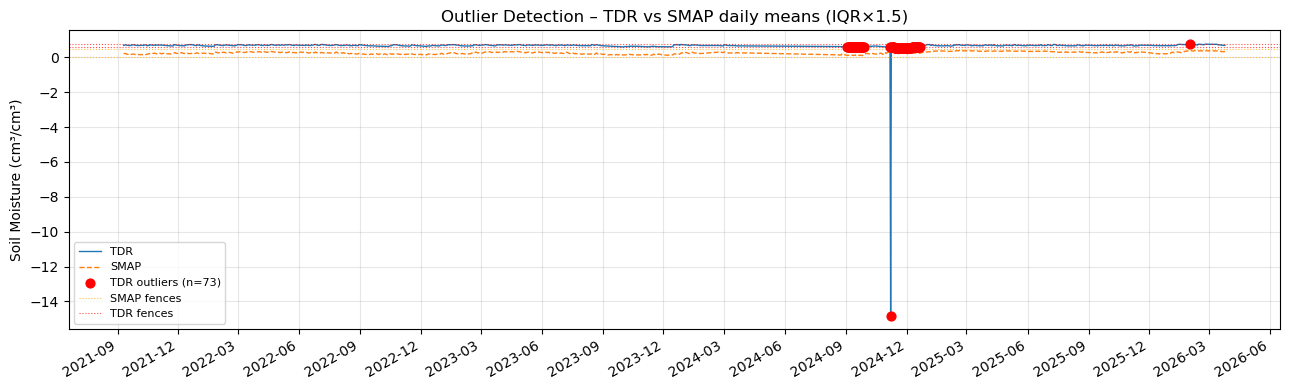

Figure saved to resultados/outlier_detection_TDR_SMAP.png


In [4]:
# --- Outlier detection (IQR method) on the merged daily data ---

def find_outliers_iqr(series, label, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - k * IQR, Q3 + k * IQR
    outliers = series[(series < lo) | (series > hi)]
    print(f"\n{'='*55}")
    print(f"Outliers in {label}  (IQR×{k})")
    print(f"  Q1={Q1:.4f}, Q3={Q3:.4f}, IQR={IQR:.4f}")
    print(f"  Lower fence: {lo:.4f}   Upper fence: {hi:.4f}")
    if outliers.empty:
        print("  → No outliers found.")
    else:
        print(f"  → {len(outliers)} outlier(s) detected:")
        print(outliers.to_string())
    return outliers, lo, hi

smap_out, smap_lo, smap_hi = find_outliers_iqr(df_cmp["SMAP_mean"], "SMAP daily mean")
tdr_out,  tdr_lo,  tdr_hi  = find_outliers_iqr(df_cmp["TDR_mean"],  "TDR daily mean")

# --- Visual: flag outliers on the time series ---
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_cmp.index, df_cmp["TDR_mean"],  label="TDR",  linewidth=1)
ax.plot(df_cmp.index, df_cmp["SMAP_mean"], label="SMAP", linewidth=1, linestyle="--")

if not smap_out.empty:
    ax.scatter(smap_out.index, smap_out.values, color="orange", zorder=5,
               s=40, label=f"SMAP outliers (n={len(smap_out)})")
if not tdr_out.empty:
    ax.scatter(tdr_out.index, tdr_out.values, color="red", zorder=5,
               s=40, label=f"TDR outliers (n={len(tdr_out)})")

ax.axhline(smap_lo, color="orange", linewidth=0.8, linestyle=":", alpha=0.7, label="SMAP fences")
ax.axhline(smap_hi, color="orange", linewidth=0.8, linestyle=":", alpha=0.7)
ax.axhline(tdr_lo,  color="red",    linewidth=0.8, linestyle=":", alpha=0.7, label="TDR fences")
ax.axhline(tdr_hi,  color="red",    linewidth=0.8, linestyle=":", alpha=0.7)

ax.set_title("Outlier Detection – TDR vs SMAP daily means (IQR×1.5)")
ax.set_ylabel("Soil Moisture (cm³/cm³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"resultados\outlier_detection_TDR_SMAP.png", dpi=150)
plt.show()
print("Figure saved to resultados/outlier_detection_TDR_SMAP.png")
